In [ ]:
import pandas as pd
iris_df= pd.read_csv("Dataset.csv", index_col = "Id")

In [ ]:
iris_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
iris_df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
from numpy import number
iris_df.corr(numeric_only=True)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


In [ ]:
#finding min and max from table's column
x_min = iris_df.SepalLengthCm.min()
x_max = iris_df.SepalLengthCm.max()
x = iris_df.SepalLengthCm


In [ ]:
normal_length = (x-x_min)/(x_max-x_min)
normal_length.head()

,SepalLengthCm
Id,
1,0.222222
2,0.166667
3,0.111111
4,0.083333
5,0.194444


<Axes: ylabel='Density'>

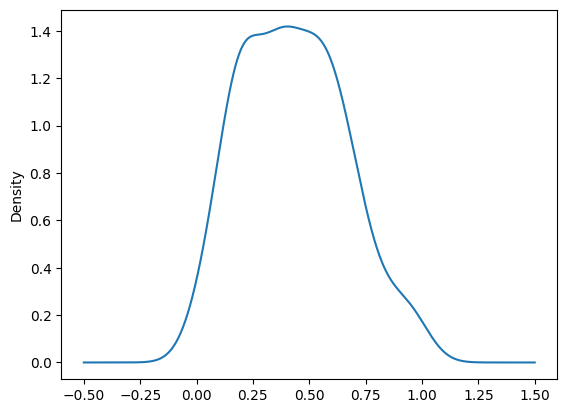

In [ ]:
normal_length.plot.kde()

In [ ]:
x_min = iris_df.PetalLengthCm.min()
x_max = iris_df.PetalLengthCm.max()
x = iris_df.PetalLengthCm
normal_length = (x-x_min)/(x_max-x_min)
normal_length.head()


,PetalLengthCm
Id,
1,0.067797
2,0.067797
3,0.050847
4,0.084746
5,0.067797


<Axes: ylabel='Density'>

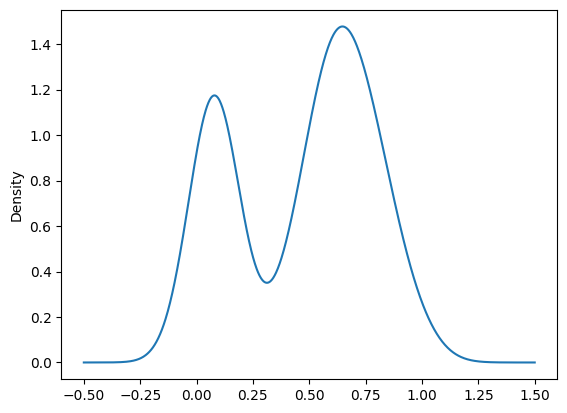

In [ ]:
normal_length.plot.kde()


In [ ]:
dataf = pd.DataFrame({
    "marks" : [20,40,60,80,1000]
})

x_min = dataf.marks.min()
x_max = dataf.marks.max()
x = dataf.marks
normal_marks = (x-x_min)/(x_max-x_min)
normal_marks.head()

,marks
0,0.000000
1,0.020408
2,0.040816
3,0.061224
4,1.000000


<Axes: ylabel='Density'>

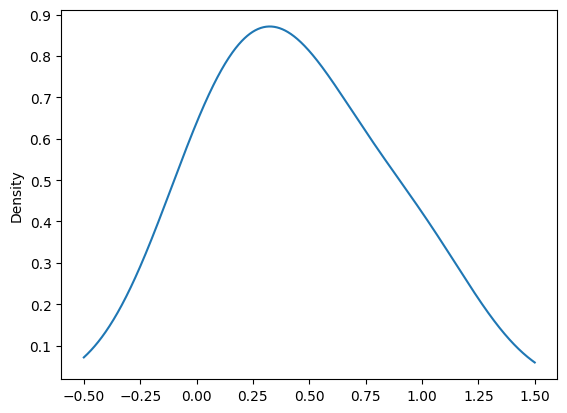

In [ ]:
normal_marks.plot.kde()

The Draw Back of min max normalization is that one greatest or lowest value can totaly change the normalization result making data reading different

Meaning it is very much sensetive

to outliers (biggest drawbacks)

In [ ]:
dataf = pd.DataFrame({
    "marks" : [20,40,60,80,120]
})

x_min = dataf.marks.min()
x_max = dataf.marks.max()
x = dataf.marks
normal_marks = (x-x_min)/(x_max-x_min)
normal_marks.head()

,marks
0,0.0
1,0.2
2,0.4
3,0.6
4,1.0


<Axes: ylabel='Density'>

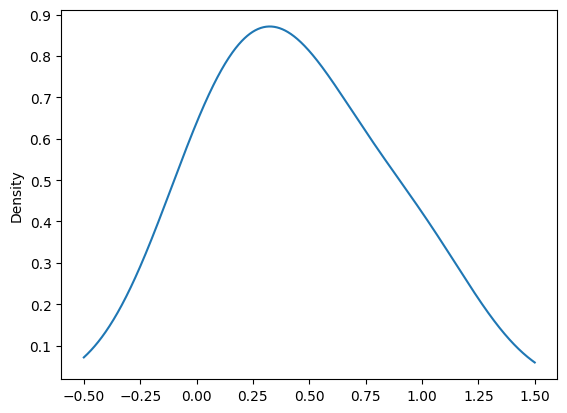

In [ ]:
normal_marks.plot.kde()

New Data can change all values

not robust for real world data

advantages

proportional spacing

monotonicity (relative order of value)

x_1 < x_2 original
x_1 < x_2 after scaling

To overcome those flaws we can use Z-score normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
minmax_scaler = MinMaxScaler(feature_range=(0,1))
norm_data = minmax_scaler.fit_transform(iris_df.drop("Species",axis =1)) #creates array
norm_df = pd.DataFrame(norm_data, columns = iris_df.drop("Species",axis =1).columns)
norm_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [ ]:
norm_df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.439167,0.467571,0.457778
std,0.230018,0.180664,0.299054,0.317984
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [ ]:
x = iris_df.SepalLengthCm
mean = iris_df.SepalLengthCm.mean()
std = iris_df.SepalLengthCm.std()

z_score_normalization = (x - mean) / std

z_score_normalization.head()


,SepalLengthCm
Id,
1,-0.897674
2,-1.139200
3,-1.380727
4,-1.501490
5,-1.018437


<Axes: ylabel='Density'>

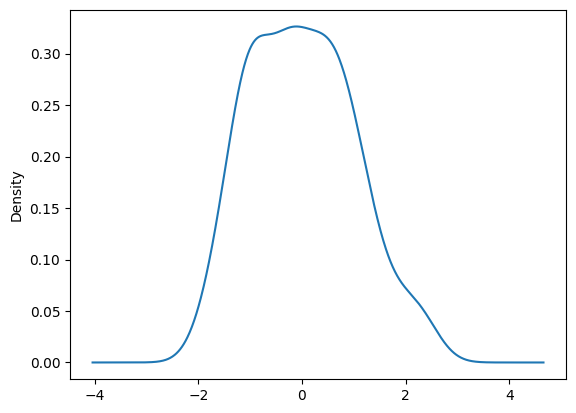

In [ ]:
z_score_normalization.plot.kde()

In [ ]:
from sklearn.preprocessing import StandardScaler
st_scalar = StandardScaler()
norm_data = st_scalar.fit_transform(iris_df.drop("Species",axis =1))
norm_df = pd.DataFrame(norm_data, columns = iris_df.drop("Species",axis =1).columns)
norm_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


In [ ]:
norm_df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-6.631732e-16,3.315866e-16,-2.842171e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.438987e+00,-1.568735e+00,-1.444450e+00
25%,-9.006812e-01,-5.877635e-01,-1.227541e+00,-1.181504e+00
50%,-5.250608e-02,-1.249576e-01,3.362659e-01,1.332259e-01
75%,6.745011e-01,5.692513e-01,7.627586e-01,7.905908e-01
max,2.492019e+00,3.114684e+00,1.786341e+00,1.710902e+00


In [ ]:
import numpy as np
data = np.arange(10,50000,50)

In [ ]:
data

array([   10,    60,   110,   160,   210,   260,   310,   360,   410,
         460,   510,   560,   610,   660,   710,   760,   810,   860,
         910,   960,  1010,  1060,  1110,  1160,  1210,  1260,  1310,
        1360,  1410,  1460,  1510,  1560,  1610,  1660,  1710,  1760,
        1810,  1860,  1910,  1960,  2010,  2060,  2110,  2160,  2210,
        2260,  2310,  2360,  2410,  2460,  2510,  2560,  2610,  2660,
        2710,  2760,  2810,  2860,  2910,  2960,  3010,  3060,  3110,
        3160,  3210,  3260,  3310,  3360,  3410,  3460,  3510,  3560,
        3610,  3660,  3710,  3760,  3810,  3860,  3910,  3960,  4010,
        4060,  4110,  4160,  4210,  4260,  4310,  4360,  4410,  4460,
        4510,  4560,  4610,  4660,  4710,  4760,  4810,  4860,  4910,
        4960,  5010,  5060,  5110,  5160,  5210,  5260,  5310,  5360,
        5410,  5460,  5510,  5560,  5610,  5660,  5710,  5760,  5810,
        5860,  5910,  5960,  6010,  6060,  6110,  6160,  6210,  6260,
        6310,  6360,

In [ ]:
np.log(data)

array([ 2.30258509,  4.09434456,  4.70048037,  5.07517382,  5.34710753,
        5.56068163,  5.7365723 ,  5.88610403,  6.01615716,  6.13122649,
        6.23441073,  6.32793678,  6.41345896,  6.49223984,  6.56526497,
        6.63331843,  6.69703425,  6.75693239,  6.8134446 ,  6.86693328,
        6.91770561,  6.96602419,  7.01211529,  7.05617528,  7.09837564,
        7.138867  ,  7.17778242,  7.21523998,  7.25134498,  7.28619171,
        7.31986493,  7.3524411 ,  7.38398946,  7.41457288,  7.44424865,
        7.47306909,  7.50108212,  7.52833177,  7.55485852,  7.58069975,
        7.60589   ,  7.63046126,  7.65444323,  7.6778635 ,  7.70074779,
        7.72312009,  7.7450028 ,  7.7664169 ,  7.78738203,  7.80791663,
        7.82803803,  7.84776254,  7.8671055 ,  7.8860814 ,  7.90470391,
        7.92298596,  7.94093976,  7.9585769 ,  7.97590836,  7.99294455,
        8.00969536,  8.02617019,  8.04237801,  8.05832731,  8.07402622,
        8.08948247,  8.10470347,  8.11969625,  8.13446757,  8.14

In [ ]:
np.log(data).max()

np.float64(10.818977964239513)

In [ ]:
transformed_data = np.log(iris_df.drop("Species",axis =1))
transformed_data.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,,,,
1,1.629241,1.252763,0.336472,-1.609438
2,1.589235,1.098612,0.336472,-1.609438
3,1.547563,1.163151,0.262364,-1.609438
4,1.526056,1.131402,0.405465,-1.609438
5,1.609438,1.280934,0.336472,-1.609438


In [ ]:
transformed_data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,1.755393,1.106442,1.175498,-0.176944
std,0.141189,0.142341,0.589493,0.991394
min,1.458615,0.693147,0.000000,-2.302585
25%,1.629241,1.029619,0.470004,-1.203973
50%,1.757858,1.098612,1.470110,0.262364
75%,1.856298,1.193922,1.629241,0.587787
max,2.066863,1.481605,1.931521,0.916291


In [ ]:
power_factor = 0.7
normal_length = np.sign(iris_df.SepalLengthCm) * np.power(np.abs(iris_df.SepalLengthCm), power_factor)
normal_length.head()

,SepalLengthCm
Id,
1,3.128233
2,3.041846
3,2.954395
4,2.910251
5,3.085169


In [ ]:
from scipy.stats import skewnorm
data = skewnorm.rvs(10,size = 1000)
data


array([ 1.51789395e+00,  3.33597401e-01,  1.88745803e+00,  4.51670300e-01,
        9.32166972e-01,  1.64929193e+00,  3.55941011e-01,  8.57167955e-01,
        1.63347586e+00,  4.44605433e-01,  8.77511111e-01,  8.27431719e-01,
        7.91785972e-01,  2.41530182e-01,  6.58808586e-01,  1.12975299e+00,
        9.46448149e-01,  5.87286282e-01,  7.60433464e-01,  5.30815860e-01,
        1.47461411e-01,  1.61069275e-01,  4.07983291e-02,  1.01689712e-01,
        1.16955520e-01,  1.08089403e+00,  1.21466929e-01,  2.45201364e-01,
        3.47804710e-01,  4.32570104e-01,  1.85172197e+00,  4.29889217e-01,
        6.27120313e-01,  1.55546332e+00,  4.95125018e-01,  4.15716429e-01,
        4.57518984e-01,  9.99097091e-01,  4.20308177e-01,  1.53674035e+00,
        1.04613839e+00,  6.50307500e-01,  9.70879732e-01,  2.21600201e+00,
        4.33894593e-01,  1.22612193e-01,  1.19440335e+00,  9.48521673e-01,
        7.40192827e-02,  7.28014352e-01,  7.63983241e-01,  7.33180374e-01,
        2.73774227e-01,  

In [ ]:
df = pd.DataFrame(data)
df.head()

,0
0,1.517894
1,0.333597
2,1.887458
3,0.451670
4,0.932167
